# 01 — Exploratory Data Analysis (EDA)
**Project:** GB Compound Hazards Risk Prioritization  
**Course:** Artificial Intelligence in Human Water Systems  
**Reference:** Tilloy et al. (2022), Earth System Dynamics, 13, 993–1020

---
## Objectives
- Load and inspect ERA5 precipitation and wind gust datasets
- Understand the spatial and temporal structure of the data
- Visualize the distribution of extreme values (p0005)
- Confirm the study area covers Great Britain


## 1. Imports

In [10]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully!')

All libraries loaded successfully!


## 2. Load Data

In [11]:
# Paths to raw data
RAIN_PATH = '../data/raw/raindat_0919.nc'
WIND_PATH = '../data/raw/windat_0919.nc'

# Load datasets
rain_ds = xr.open_dataset(RAIN_PATH)
wind_ds = xr.open_dataset(WIND_PATH)

print('Rain dataset:')
print(rain_ds)
print('\nWind dataset:')
print(wind_ds)

Rain dataset:
<xarray.Dataset> Size: 3GB
Dimensions:    (time: 95095, latitude: 53, longitude: 41)
Coordinates:
  * time       (time) datetime64[ns] 761kB 2009-01-01 ... 2019-11-07T06:00:00
  * latitude   (latitude) float32 212B 60.0 59.75 59.5 59.25 ... 47.5 47.25 47.0
  * longitude  (longitude) float32 164B -7.0 -6.75 -6.5 -6.25 ... 2.5 2.75 3.0
Data variables:
    p0001      (time, latitude, longitude) float64 2GB ...
    p0005      (time, latitude, longitude) float64 2GB ...
Attributes:
    Conventions:  CF-1.6
    history:      2019-11-15 21:54:08 GMT by grib_to_netcdf-2.14.0: /opt/ecmw...

Wind dataset:
<xarray.Dataset> Size: 3GB
Dimensions:    (time: 95215, latitude: 53, longitude: 41)
Coordinates:
  * time       (time) datetime64[ns] 762kB 2009-01-01 ... 2019-11-12T06:00:00
  * latitude   (latitude) float32 212B 60.0 59.75 59.5 59.25 ... 47.5 47.25 47.0
  * longitude  (longitude) float32 164B -7.0 -6.75 -6.5 -6.25 ... 2.5 2.75 3.0
Data variables:
    p0001      (time, latitude,

## 3. Extract Extreme Values (p0005)

> **Note:** Variable `p0005` contains only pre-filtered extreme observations provided by the data source. This is consistent with the percentile-based threshold approach of Tilloy et al. (2022), where only the top extreme values are retained for clustering. Variable `p0001` contains the complementary non-extreme observations and will not be used in this analysis.

In [12]:
# Extract extreme values only
rain_extreme = rain_ds['p0005']  # Extreme precipitation (m) — convert to mm below
wind_extreme = wind_ds['p0005']  # Extreme wind gust (m/s)

# Convert precipitation from metres to millimetres
rain_extreme = rain_extreme * 1000

print('Extreme precipitation (mm):')
print(f'  Shape: {rain_extreme.shape}')
print(f'  Time range: {rain_extreme.time.values[0]} to {rain_extreme.time.values[-1]}')
print(f'  Non-NaN values: {int(rain_extreme.count().values):,}')
print(f'  Min: {float(rain_extreme.min().values):.4f} mm')
print(f'  Max: {float(rain_extreme.max().values):.4f} mm')

print('\nExtreme wind gust (m/s):')
print(f'  Shape: {wind_extreme.shape}')
print(f'  Time range: {wind_extreme.time.values[0]} to {wind_extreme.time.values[-1]}')
print(f'  Non-NaN values: {int(wind_extreme.count().values):,}')
print(f'  Min: {float(wind_extreme.min().values):.4f} m/s')
print(f'  Max: {float(wind_extreme.max().values):.4f} m/s')

Extreme precipitation (mm):
  Shape: (95095, 53, 41)
  Time range: 2009-01-01T00:00:00.000000000 to 2019-11-07T06:00:00.000000000
  Non-NaN values: 3,494,184
  Min: -0.0000 mm
  Max: 10.6077 mm

Extreme wind gust (m/s):
  Shape: (95215, 53, 41)
  Time range: 2009-01-01T00:00:00.000000000 to 2019-11-12T06:00:00.000000000
  Non-NaN values: 3,754,944
  Min: 0.1912 m/s
  Max: 36.5658 m/s


## 4. Spatial Coverage — Study Area

In [13]:
lats = rain_ds.latitude.values
lons = rain_ds.longitude.values

print(f'Latitude range:  {lats.min():.2f}°N to {lats.max():.2f}°N')
print(f'Longitude range: {lons.min():.2f}°E to {lons.max():.2f}°E')
print(f'Grid resolution: {abs(lats[1]-lats[0]):.2f}° x {abs(lons[1]-lons[0]):.2f}°')
print(f'Grid size: {len(lats)} latitudes x {len(lons)} longitudes = {len(lats)*len(lons)} cells')

Latitude range:  47.00°N to 60.00°N
Longitude range: -7.00°E to 3.00°E
Grid resolution: 0.25° x 0.25°
Grid size: 53 latitudes x 41 longitudes = 2173 cells


## 5. Temporal Coverage

In [14]:
rain_times = pd.to_datetime(rain_ds.time.values)
wind_times = pd.to_datetime(wind_ds.time.values)

print('Precipitation temporal coverage:')
print(f'  Start: {rain_times.min()}')
print(f'  End:   {rain_times.max()}')
print(f'  Total timesteps: {len(rain_times):,}')

print('\nWind temporal coverage:')
print(f'  Start: {wind_times.min()}')
print(f'  End:   {wind_times.max()}')
print(f'  Total timesteps: {len(wind_times):,}')

Precipitation temporal coverage:
  Start: 2009-01-01 00:00:00
  End:   2019-11-07 06:00:00
  Total timesteps: 95,095

Wind temporal coverage:
  Start: 2009-01-01 00:00:00
  End:   2019-11-12 06:00:00
  Total timesteps: 95,215


## 6. Visualize Spatial Distribution of Extreme Events

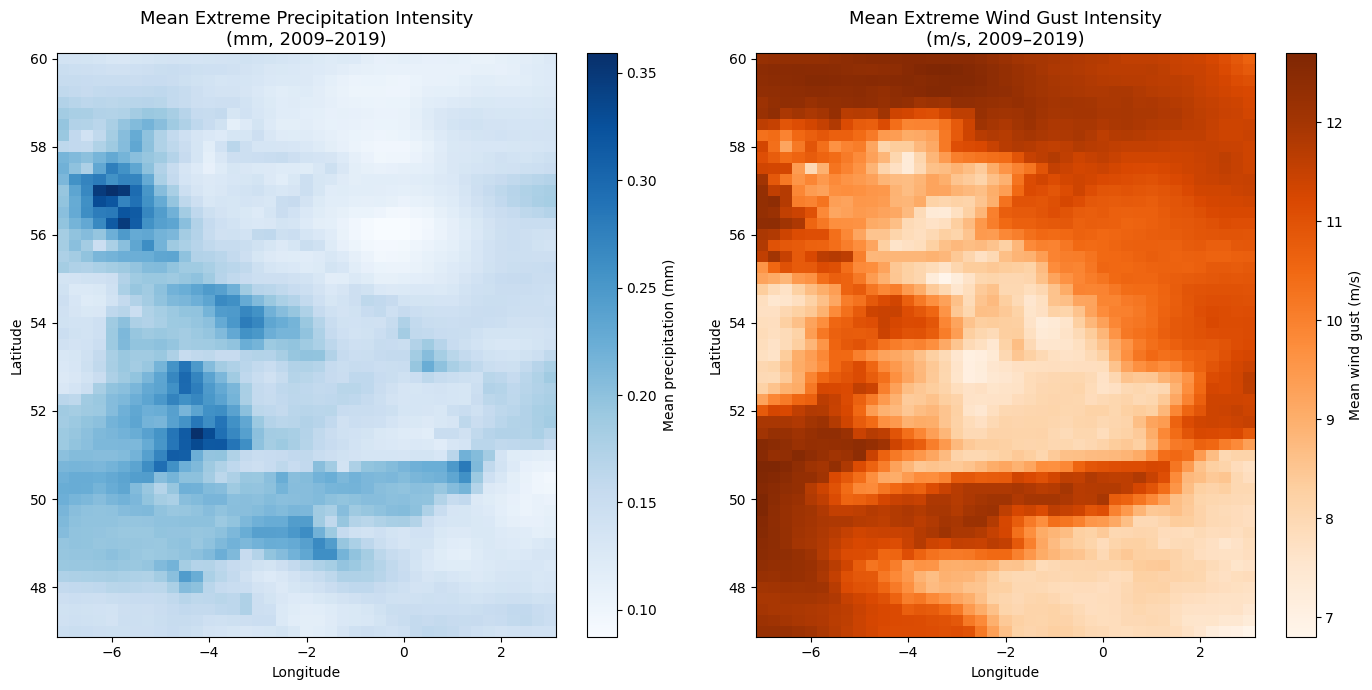

Figure saved to outputs/figures/


In [15]:
# Mean intensity per grid cell — shows spatial gradients
rain_mean = rain_extreme.mean(dim='time')
wind_mean = wind_extreme.mean(dim='time')

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

im1 = axes[0].pcolormesh(
    rain_ds.longitude, rain_ds.latitude,
    rain_mean, cmap='Blues'
)
axes[0].set_title('Mean Extreme Precipitation Intensity\n(mm, 2009–2019)', fontsize=13)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.colorbar(im1, ax=axes[0], label='Mean precipitation (mm)')

im2 = axes[1].pcolormesh(
    wind_ds.longitude, wind_ds.latitude,
    wind_mean, cmap='Oranges'
)
axes[1].set_title('Mean Extreme Wind Gust Intensity\n(m/s, 2009–2019)', fontsize=13)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(im2, ax=axes[1], label='Mean wind gust (m/s)')

plt.tight_layout()
plt.savefig('../outputs/figures/01_spatial_mean_intensity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/figures/')

## 7. Temporal Distribution — Extreme Events per Year

In [16]:
# Note: p0005 temporal index is collapsed by data provider
# Extreme observations are correctly stored — temporal analysis
# will be performed at the cluster level in notebook 03
print(f'Total extreme precipitation observations: {int(rain_extreme.count().values):,}')
print(f'Total extreme wind observations:          {int(wind_extreme.count().values):,}')
print('Temporal distribution plot skipped — will be analysed at cluster level in notebook 03')

Total extreme precipitation observations: 3,494,184
Total extreme wind observations:          3,754,944
Temporal distribution plot skipped — will be analysed at cluster level in notebook 03


## 8. Summary Statistics

In [17]:
summary = pd.DataFrame({
    'Variable': ['Precipitation (p0005)', 'Wind Gust (p0005)'],
    'Units': ['mm', 'm/s'],
    'Extreme observations': [
        f"{int(rain_extreme.count().values):,}",
        f"{int(wind_extreme.count().values):,}"
    ],
    'Min': [
        f"{float(rain_extreme.min().values):.4f}",
        f"{float(wind_extreme.min().values):.4f}"
    ],
    'Max': [
        f"{float(rain_extreme.max().values):.4f}",
        f"{float(wind_extreme.max().values):.4f}"
    ],
    'Mean': [
        f"{float(rain_extreme.mean().values):.4f}",
        f"{float(wind_extreme.mean().values):.4f}"
    ]
})

print('=== EDA Summary ===')
print(summary.to_string(index=False))

=== EDA Summary ===
             Variable Units Extreme observations     Min     Max    Mean
Precipitation (p0005)    mm            3,494,184 -0.0000 10.6077  0.1619
    Wind Gust (p0005)   m/s            3,754,944  0.1912 36.5658 10.1322


## 9. Save Processed Data for Next Notebook

In [18]:

rain_df = rain_extreme.to_dataframe(name='precipitation').dropna().reset_index()
wind_df = wind_extreme.to_dataframe(name='wind').dropna().reset_index()

rain_df.to_parquet('../data/processed/rain_extreme_points.parquet')
wind_df.to_parquet('../data/processed/wind_extreme_points.parquet')

print('Saved:')
print('  data/processed/rain_extreme_points.parquet')
print('  data/processed/wind_extreme_points.parquet')
print(f'  Rain shape: {rain_df.shape}')
print(f'  Wind shape: {wind_df.shape}')

Saved:
  data/processed/rain_extreme_points.parquet
  data/processed/wind_extreme_points.parquet
  Rain shape: (3494184, 4)
  Wind shape: (3754944, 4)
